# 23CSE301 Machine Learning - Capstone Project

## Classification Track - Part A

### Bank Marketing Dataset

**Algorithms:**
1. Logistic Regression
2. K-Nearest Neighbors
3. Gaussian Naive Bayes
4. Decision Tree Classifier
5. Support Vector Machine

---

### Problem Statement
The objective of this classification project is to predict whether a bank customer will subscribe to a term deposit (binary target variable `y`: `yes` or `no`) based on direct telemarketing campaign data from a Portuguese banking institution. The dataset encompasses client demographics, financial indicators, past contact interactions, and macroeconomic attributes. Accurately predicting customer subscription propensity enables the institution to optimize marketing resource allocation, target high-probability prospective clients, and improve campaign efficiency.

In accordance with the 23CSE301 Capstone Project Guidelines, this notebook implements Part A of the Classification Track, covering the five core algorithms evaluated in Review 1. All models are trained and tested on an identical stratified split with strict prevention of data leakage.


## 2. Import Required Libraries

This section imports the necessary libraries for data processing, exploratory data analysis, pipeline creation, model training, hyperparameter tuning, and performance evaluation.

A fixed random seed (`RANDOM_STATE = 42`) is established to guarantee reproducibility across all data splits and randomized estimators.


In [1]:
# Core data manipulation and numerical libraries
import os
import numpy as np
import pandas as pd

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn model selection and validation
from sklearn.model_selection import train_test_split, GridSearchCV

# Scikit-learn preprocessing and pipeline utilities
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Scikit-learn classification algorithms (Part A)
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.svm import SVC

# Scikit-learn evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

# Plot formatting and styling
sns.set_theme(style="whitegrid", palette="tab10")
plt.rcParams["figure.autolayout"] = True

# Deterministic random seed
RANDOM_STATE = 42


## 3. Load Dataset

Loading the Bank Marketing dataset (`bank-full.csv`). The file uses semicolon delimiters (`sep=";"`). The path is verified to ensure robust loading whether executed from the project root or the notebooks directory.


In [2]:
# Locate bank-full.csv (checking current directory and common relative data paths)
csv_filename = "bank-full.csv"
if os.path.exists(csv_filename):
    csv_path = csv_filename
elif os.path.exists(os.path.join("data", csv_filename)):
    csv_path = os.path.join("data", csv_filename)
elif os.path.exists(os.path.join("..", "data", csv_filename)):
    csv_path = os.path.join("..", "data", csv_filename)
else:
    csv_path = csv_filename

df = pd.read_csv(csv_path, sep=";")
print(f"Dataset successfully loaded from: {csv_path}")


Dataset successfully loaded from: bank-full.csv


In [3]:
# Display first 5 rows
print("--- First 5 Rows ---")
display(df.head())

# Display last 5 rows
print("--- Last 5 Rows ---")
display(df.tail())

# Dataset shape
print(f"\nDataset Dimensions: {df.shape[0]} rows, {df.shape[1]} columns")

# Column names and data types
print("\n--- Column Names & Data Types ---")
display(df.dtypes.to_frame(name="Data Type"))

# DataFrame info
print("\n--- DataFrame Information ---")
df.info()


--- First 5 Rows ---


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


--- Last 5 Rows ---


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
45206,51,technician,married,tertiary,no,825,no,no,cellular,17,nov,977,3,-1,0,unknown,yes
45207,71,retired,divorced,primary,no,1729,no,no,cellular,17,nov,456,2,-1,0,unknown,yes
45208,72,retired,married,secondary,no,5715,no,no,cellular,17,nov,1127,5,184,3,success,yes
45209,57,blue-collar,married,secondary,no,668,no,no,telephone,17,nov,508,4,-1,0,unknown,no
45210,37,entrepreneur,married,secondary,no,2971,no,no,cellular,17,nov,361,2,188,11,other,no



Dataset Dimensions: 45211 rows, 17 columns

--- Column Names & Data Types ---


,Data Type
age,int64
job,object
marital,object
education,object
default,object
balance,int64
housing,object
loan,object
contact,object
day,int64



--- DataFrame Information ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


## 4. Dataset Audit

A rigorous dataset audit assesses data hygiene prior to model construction:
- Verification of missing values (`NaN` / `null`)
- Detection of duplicate records
- Examination of numerical feature distributions and ranges
- Examination of categorical unique value counts and cardinality
- Identification and enumeration of implicit missing values recorded as `"unknown"`


In [4]:
# Missing values audit
missing_counts = df.isnull().sum()
missing_pct = (missing_counts / len(df)) * 100
missing_df = pd.DataFrame({"Missing Count": missing_counts, "Percentage (%)": missing_pct})
print("--- Missing Values Audit ---")
display(missing_df)

# Duplicate records audit
duplicate_count = df.duplicated().sum()
print(f"\nDuplicate Rows Detected: {duplicate_count}")


--- Missing Values Audit ---


,Missing Count,Percentage (%)
age,0,0.0
job,0,0.0
marital,0,0.0
education,0,0.0
default,0,0.0
balance,0,0.0
housing,0,0.0
loan,0,0.0
contact,0,0.0
day,0,0.0



Duplicate Rows Detected: 0


In [5]:
# Statistical summary of numerical features
print("--- Numerical Features Statistical Summary ---")
display(df.describe().T)

# Statistical summary of categorical features
print("\n--- Categorical Features Statistical Summary ---")
display(df.describe(include=["object"]).T)


--- Numerical Features Statistical Summary ---


,count,mean,std,min,25%,50%,75%,max
age,45211.0,40.936210,10.618762,18.0,33.0,39.0,48.0,95.0
balance,45211.0,1362.272058,3044.765829,-8019.0,72.0,448.0,1428.0,102127.0
day,45211.0,15.806419,8.322476,1.0,8.0,16.0,21.0,31.0
duration,45211.0,258.163080,257.527812,0.0,103.0,180.0,319.0,4918.0
campaign,45211.0,2.763841,3.098021,1.0,1.0,2.0,3.0,63.0
pdays,45211.0,40.197828,100.128746,-1.0,-1.0,-1.0,-1.0,871.0
previous,45211.0,0.580323,2.303441,0.0,0.0,0.0,0.0,275.0



--- Categorical Features Statistical Summary ---


,count,unique,top,freq
job,45211,12,blue-collar,9732
marital,45211,3,married,27214
education,45211,4,secondary,23202
default,45211,2,no,44396
housing,45211,2,yes,25130
loan,45211,2,no,37967
contact,45211,3,cellular,29285
month,45211,12,may,13766
poutcome,45211,4,unknown,36959
y,45211,2,no,39922


In [6]:
# Categorical unique values audit
print("--- Categorical Unique Values ---")
cat_cols = df.select_dtypes(include=["object"]).columns
for col in cat_cols:
    print(f"Column '{col}' ({df[col].nunique()} unique): {df[col].unique().tolist()[:8]}")

# Audit 'unknown' values across columns
unknown_counts = (df == "unknown").sum()
unknown_df = pd.DataFrame({
    "Unknown Count": unknown_counts[unknown_counts > 0],
    "Percentage (%)": ((unknown_counts[unknown_counts > 0] / len(df)) * 100).round(2)
})
print("\n--- Implicit Missing Values ('unknown') Audit ---")
display(unknown_df)


--- Categorical Unique Values ---
Column 'job' (12 unique): ['management', 'technician', 'entrepreneur', 'blue-collar', 'unknown', 'retired', 'admin.', 'services']
Column 'marital' (3 unique): ['married', 'single', 'divorced']
Column 'education' (4 unique): ['tertiary', 'secondary', 'unknown', 'primary']
Column 'default' (2 unique): ['no', 'yes']
Column 'housing' (2 unique): ['yes', 'no']
Column 'loan' (2 unique): ['no', 'yes']
Column 'contact' (3 unique): ['unknown', 'cellular', 'telephone']
Column 'month' (12 unique): ['may', 'jun', 'jul', 'aug', 'oct', 'nov', 'dec', 'jan']
Column 'poutcome' (4 unique): ['unknown', 'failure', 'other', 'success']
Column 'y' (2 unique): ['no', 'yes']

--- Implicit Missing Values ('unknown') Audit ---


,Unknown Count,Percentage (%)
job,288,0.64
education,1857,4.11
contact,13020,28.80
poutcome,36959,81.75


> **Technical Note on `"unknown"` Values**: 
> `"unknown"` indicates non-disclosed or uncollected customer responses (e.g., in contact method, education, or poutcome). Removing these rows would eliminate substantial training data and introduce non-random attrition bias. Therefore, `"unknown"` is preserved as an informative category level for encoding.


## 5. Exploratory Data Analysis (EDA)

In alignment with the official rubric, the exploratory data analysis includes:
1. **Target distribution** (counts and proportions)
2. **Numerical feature distributions**
3. **Categorical feature distributions**
4. **Correlation heatmap** for continuous features
5. **Bivariate scatter plots** exploring relationships between features and the target variable


### 5.1 Target Variable Distribution (`y`)
Visualizing the distribution of the binary target variable `y`.


C:\Users\sanja\AppData\Local\Temp\ipykernel_14316\3652684653.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="y", ax=axes[0], palette="tab10", order=["no", "yes"])


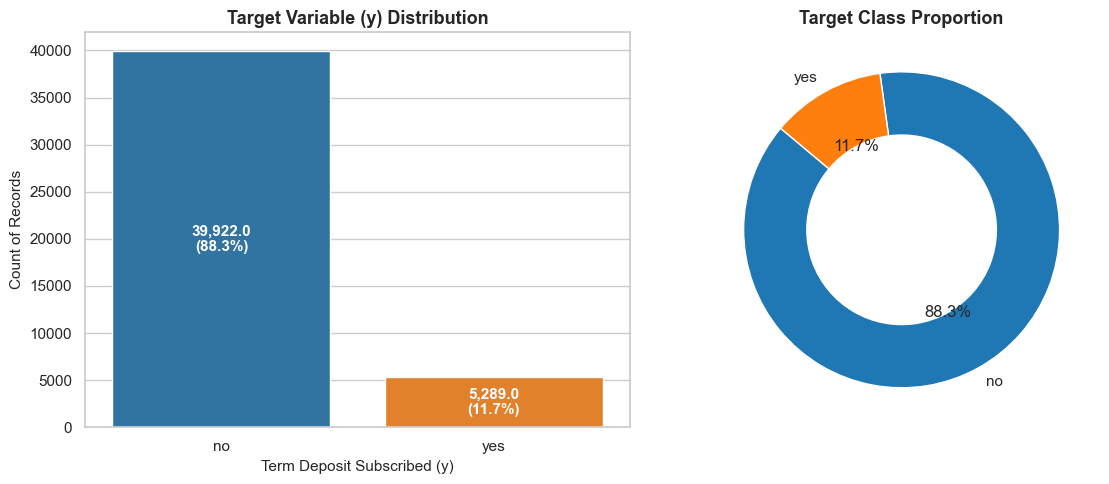

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Target count plot
sns.countplot(data=df, x="y", ax=axes[0], palette="tab10", order=["no", "yes"])
axes[0].set_title("Target Variable (y) Distribution", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Term Deposit Subscribed (y)", fontsize=11)
axes[0].set_ylabel("Count of Records", fontsize=11)

# Annotate counts and percentages
total_records = len(df)
for p in axes[0].patches:
    h = p.get_height()
    axes[0].annotate(f"{h:,}\n({(h/total_records)*100:.1f}%)",
                     (p.get_x() + p.get_width() / 2., h / 2),
                     ha="center", va="center", fontsize=11, color="white", fontweight="bold")

# Target proportion donut chart
y_counts = df["y"].value_counts()
axes[1].pie(y_counts, labels=y_counts.index, autopct="%1.1f%%", startangle=140,
           colors=sns.color_palette("tab10")[:2], wedgeprops=dict(width=0.4, edgecolor="w"))
axes[1].set_title("Target Class Proportion", fontsize=13, fontweight="bold")

plt.tight_layout()
plt.show()


### Student Observation
- **Severe Class Imbalance**: The dataset contains 39,922 'no' (88.3%) and only 5,289 'yes' (11.7%) responses. This represents an approximate 7.5:1 imbalance ratio.
- **Evaluation Metric Implications**: Simple accuracy is misleading here. A naive model predicting 'no' for every single instance would achieve 88.3% accuracy but zero utility. Therefore, model performance must be evaluated using Weighted F1-score, Precision, Recall, and ROC-AUC rather than raw accuracy alone.


### 5.2 Distribution of Numerical Features
Plotting histogram distributions with Kernel Density Estimation (KDE) for continuous variables.


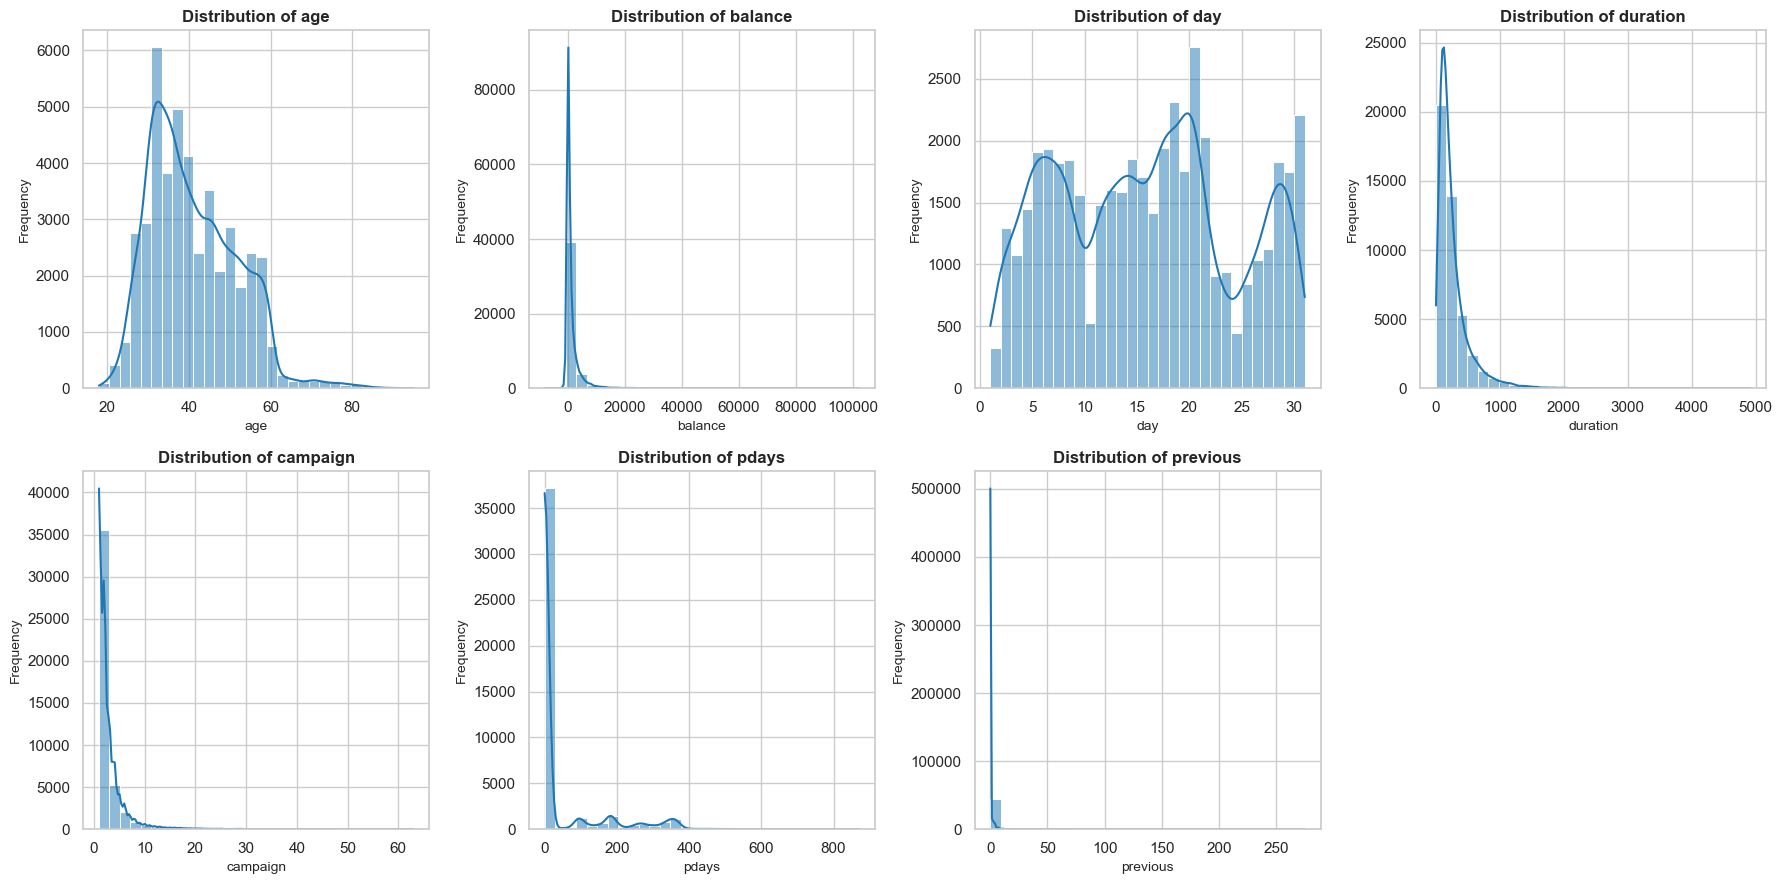

In [8]:
num_features_eda = df.select_dtypes(include=["int64", "float64"]).columns.tolist()

fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(18, 9))
axes = axes.flatten()

for i, col in enumerate(num_features_eda):
    sns.histplot(df[col], kde=True, ax=axes[i], color=sns.color_palette("tab10")[0], bins=30)
    axes[i].set_title(f"Distribution of {col}", fontsize=12, fontweight="bold")
    axes[i].set_xlabel(col, fontsize=10)
    axes[i].set_ylabel("Frequency", fontsize=10)

# Remove unused subplots
for j in range(len(num_features_eda), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


### Student Observation
- **Skewness and Outliers**: Numerical features like `duration`, `balance`, and `campaign` are heavily right-skewed. Most clients have relatively small balances (< 2,000 euros) and short call durations (< 300 seconds), while a few extreme outliers stretch the distributions.
- **Special Structure in `pdays`**: `pdays` has an overwhelming peak at -1 (over 80% of records), indicating clients who were never previously contacted.
- **Need for Scaling**: Because features like `balance` (range: -8k to 102k) and `duration` (0 to 4900s) span orders of magnitude wider ranges than `age` or `campaign`, applying `StandardScaler` is essential so that distance-based models (KNN, SVM) are not biased toward large-scale features.


### 5.3 Categorical Feature Distributions
Analyzing category frequencies across demographic and customer attributes.


C:\Users\sanja\AppData\Local\Temp\ipykernel_14316\2846343176.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y="job", order=df["job"].value_counts().index, ax=axes[0, 0], palette="tab10")
C:\Users\sanja\AppData\Local\Temp\ipykernel_14316\2846343176.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="marital", order=df["marital"].value_counts().index, ax=axes[0, 1], palette="tab10")
C:\Users\sanja\AppData\Local\Temp\ipykernel_14316\2846343176.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="educ

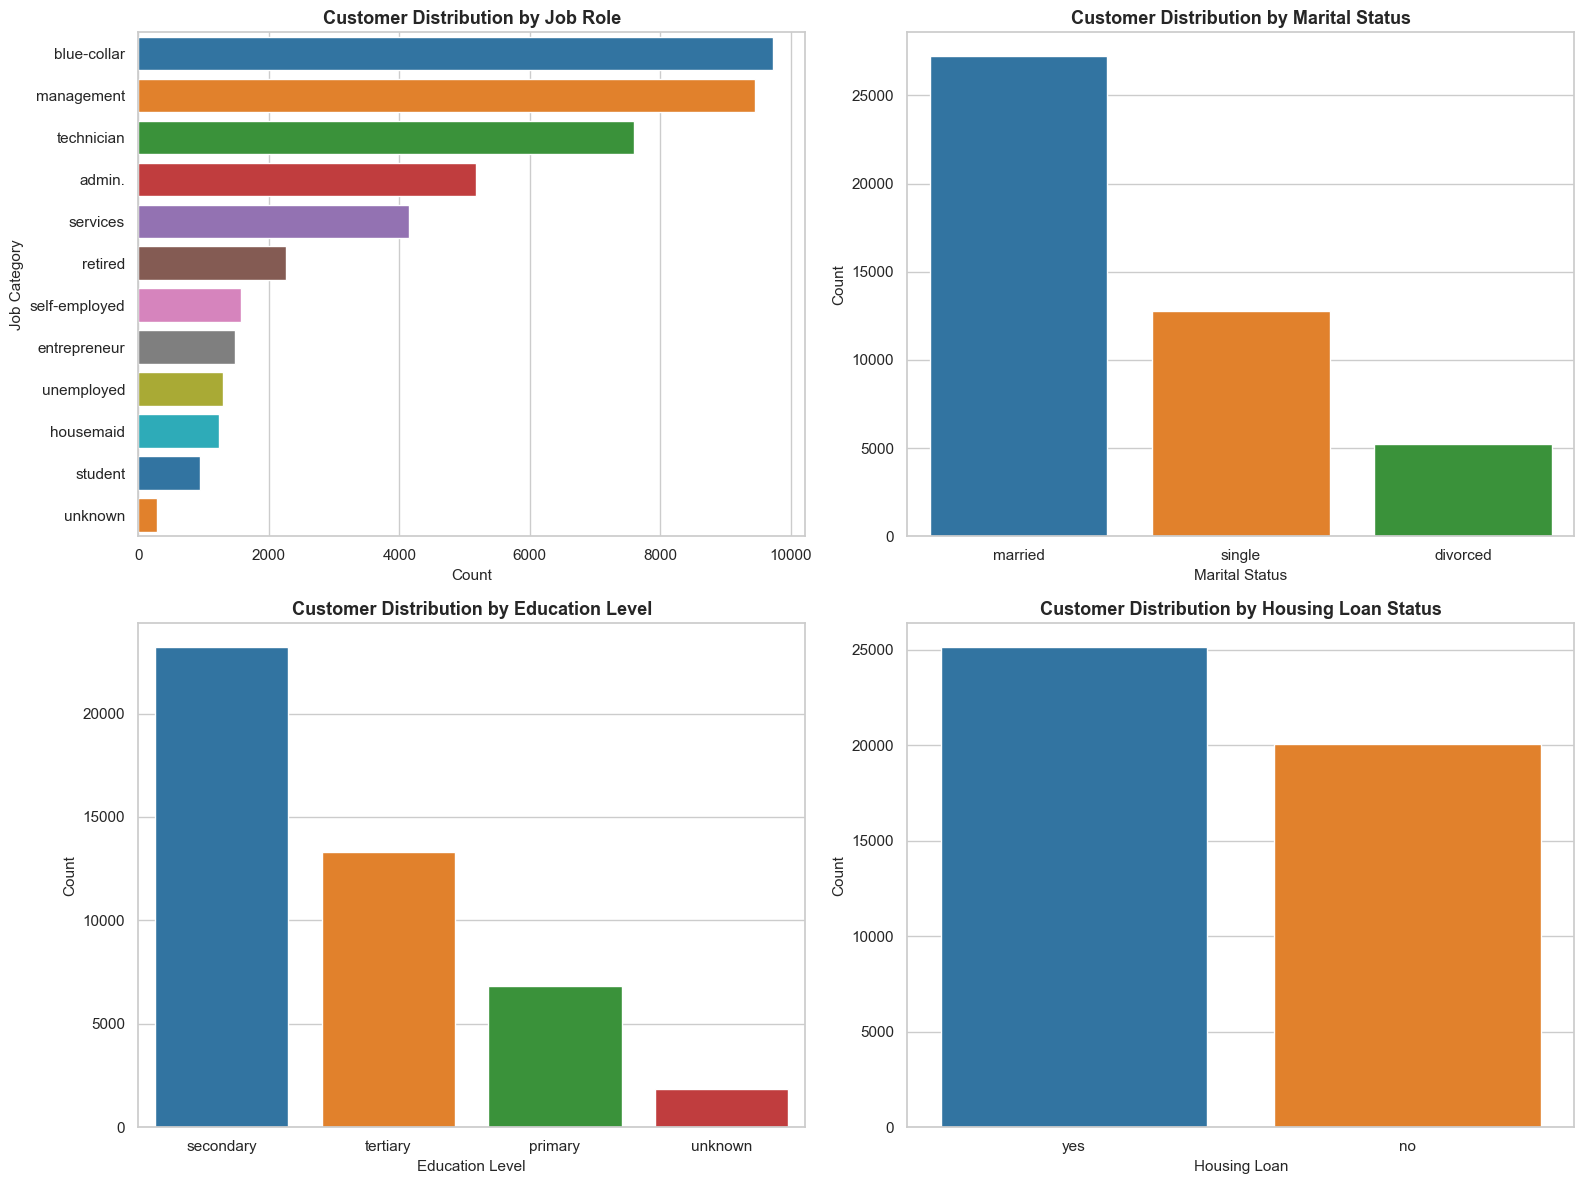

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Job distribution
sns.countplot(data=df, y="job", order=df["job"].value_counts().index, ax=axes[0, 0], palette="tab10")
axes[0, 0].set_title("Customer Distribution by Job Role", fontsize=13, fontweight="bold")
axes[0, 0].set_xlabel("Count", fontsize=11)
axes[0, 0].set_ylabel("Job Category", fontsize=11)

# Marital status distribution
sns.countplot(data=df, x="marital", order=df["marital"].value_counts().index, ax=axes[0, 1], palette="tab10")
axes[0, 1].set_title("Customer Distribution by Marital Status", fontsize=13, fontweight="bold")
axes[0, 1].set_xlabel("Marital Status", fontsize=11)
axes[0, 1].set_ylabel("Count", fontsize=11)

# Education level distribution
sns.countplot(data=df, x="education", order=df["education"].value_counts().index, ax=axes[1, 0], palette="tab10")
axes[1, 0].set_title("Customer Distribution by Education Level", fontsize=13, fontweight="bold")
axes[1, 0].set_xlabel("Education Level", fontsize=11)
axes[1, 0].set_ylabel("Count", fontsize=11)

# Housing loan status
sns.countplot(data=df, x="housing", order=df["housing"].value_counts().index, ax=axes[1, 1], palette="tab10")
axes[1, 1].set_title("Customer Distribution by Housing Loan Status", fontsize=13, fontweight="bold")
axes[1, 1].set_xlabel("Housing Loan", fontsize=11)
axes[1, 1].set_ylabel("Count", fontsize=11)

plt.tight_layout()
plt.show()


### Student Observation
- **Dominant Segments**: The most frequent job categories are `blue-collar`, `management`, and `technician`. Together they represent the majority of contacted customers.
- **Demographic Profile**: Most clients are married (> 60%) and have completed secondary education. Additionally, over 55% have an existing housing loan, which could directly affect their financial flexibility to open a term deposit.
- **Encoding Strategy**: Since these categories have no natural ordinal ranking, One-Hot Encoding (`drop='first'`) is appropriate to avoid introducing artificial ordinality while preventing the dummy variable trap.


### 5.4 Correlation Heatmap (Numerical Features)
Inspecting linear relationships and collinearity among continuous attributes.


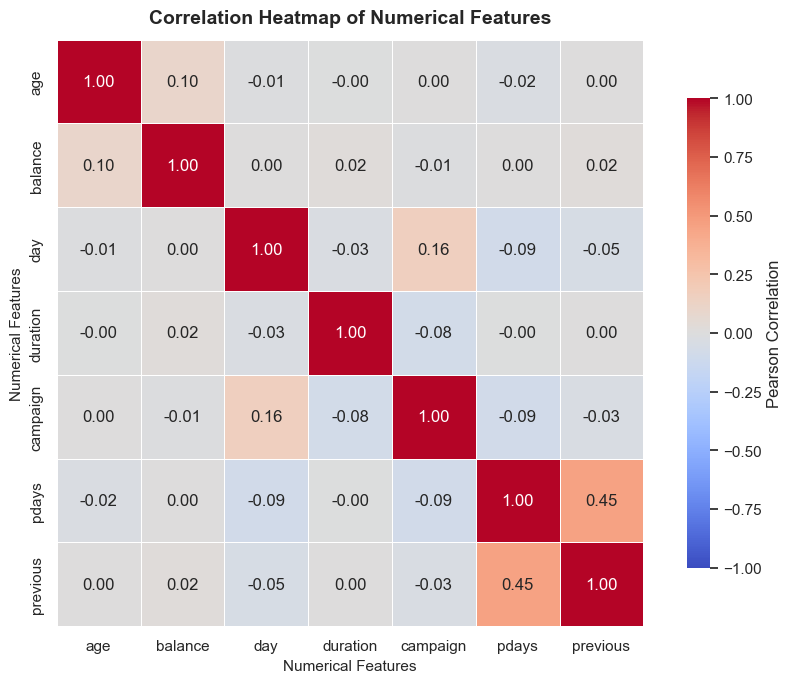

In [10]:
corr_matrix = df[num_features_eda].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8, "label": "Pearson Correlation"})
plt.title("Correlation Heatmap of Numerical Features", fontsize=14, fontweight="bold", pad=12)
plt.xlabel("Numerical Features", fontsize=11)
plt.ylabel("Numerical Features", fontsize=11)
plt.tight_layout()
plt.show()


### Student Observation
- **Low Overall Collinearity**: Pairwise linear correlations between continuous features are generally very weak (most $|r| < 0.10$). This indicates little to no severe collinearity among the numerical predictors.
- **Campaign History Correlation**: The only moderate correlation is between `pdays` and `previous` ($r \approx 0.45$). This is expected because both variables directly capture contact history from prior marketing efforts.
- **Implications for Linear Models**: Because collinearity is minimal, linear models like Logistic Regression should have stable coefficient estimates without variance inflation.


### 5.5 Feature-Target Scatter Plots
Evaluating relationships between numerical attributes with color-encoding by target outcome.

*Note: The target is used here strictly for visualization color-encoding and does not replace model preprocessing.*


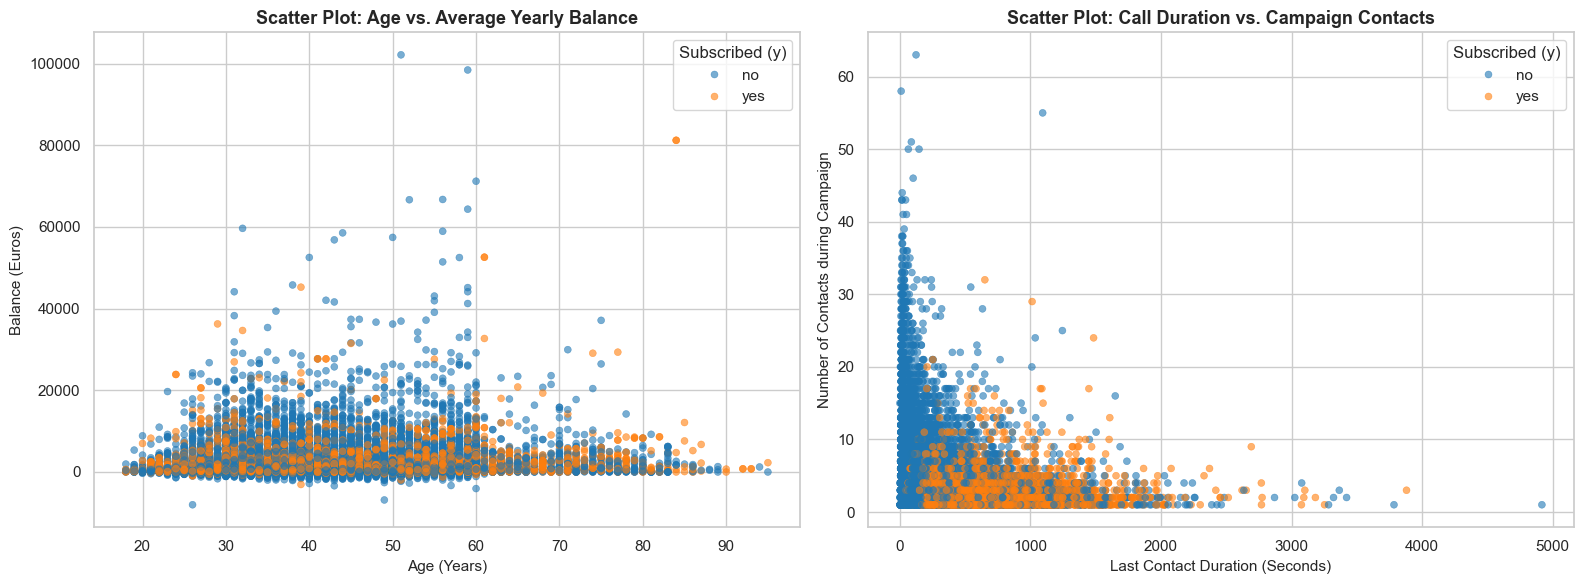

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Scatter 1: Age vs Balance conditioned on Target
sns.scatterplot(
    data=df,
    x="age",
    y="balance",
    hue="y",
    palette={"no": "tab:blue", "yes": "tab:orange"},
    alpha=0.6,
    edgecolor=None,
    s=25,
    ax=axes[0]
)
axes[0].set_title("Scatter Plot: Age vs. Average Yearly Balance", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Age (Years)", fontsize=11)
axes[0].set_ylabel("Balance (Euros)", fontsize=11)
axes[0].legend(title="Subscribed (y)", loc="upper right")

# Scatter 2: Call Duration vs Campaign Contacts conditioned on Target
sns.scatterplot(
    data=df,
    x="duration",
    y="campaign",
    hue="y",
    palette={"no": "tab:blue", "yes": "tab:orange"},
    alpha=0.6,
    edgecolor=None,
    s=25,
    ax=axes[1]
)
axes[1].set_title("Scatter Plot: Call Duration vs. Campaign Contacts", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Last Contact Duration (Seconds)", fontsize=11)
axes[1].set_ylabel("Number of Contacts during Campaign", fontsize=11)
axes[1].legend(title="Subscribed (y)", loc="upper right")

plt.tight_layout()
plt.show()


### Student Observation
- **Call Duration is the Strongest Separator**: Subscribed customers (`yes`) are clearly concentrated at longer call durations (especially above 300-400 seconds). Brief calls almost never result in a subscription.
- **Diminishing Returns on Campaign Contacts**: Most successful conversions occur within the first 1 to 4 contacts during a campaign. Beyond 10-15 contacts, conversions drop to near zero regardless of duration, showing clear customer fatigue.
- **Age vs. Balance Distribution**: Subscriptions are spread across all age brackets and balances without a single clean linear boundary, though a slight clustering of subscribers is visible around moderate positive balances.
